# Experiment 6: Dimensionality Reduction and Model Evaluation Using PCA

## Objective

To study the effect of dimensionality reduction using **Principal Component Analysis (PCA)** on the performance of different machine-learning classifiers.

The experiment compares two settings:

1. **Without PCA** – models are trained using the original feature space.
2. **With PCA** – models are trained using a reduced feature space.

Hyperparameter tuning and **5-fold stratified cross-validation** are used for model selection and evaluation.

The classifiers considered are:
- Support Vector Machine (SVM)
- Naïve Bayes
- k-Nearest Neighbors (KNN)
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- Stacking

> **Important:** All numerical results and interpretations in this notebook are generated from the actual execution. No performance values are assumed in advance.

## 1. Theory: Principal Component Analysis

Principal Component Analysis (PCA) is a dimensionality-reduction technique that transforms the original features into a smaller set of new variables called **principal components**.

The first principal component captures the maximum possible variance in the data. Each subsequent component captures the maximum remaining variance while being orthogonal to the previous components.

PCA can be useful when:
- many features are correlated,
- some dimensions contain redundant information,
- the feature space is high-dimensional,
- computational cost needs to be reduced,
- noise or irrelevant variation needs to be reduced.

Because PCA depends on feature variance, numerical features should generally be standardized before PCA.

### Important distinction

PCA does **not** guarantee better classification accuracy. A model may improve, remain similar, or perform worse after dimensionality reduction. The purpose of this experiment is to determine how different classifiers respond to the reduced representation.

## 2. Import Required Libraries

The following libraries are used for data handling, preprocessing, PCA, model training, hyperparameter tuning, cross-validation, and evaluation.

In [ ]:
import sys
import subprocess
import importlib.util

# Install XGBoost only if it is not already available.
if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Dataset Description

For this implementation, the **Breast Cancer Wisconsin Diagnostic dataset** available through scikit-learn is used.

The dataset contains numerical measurements derived from digitized images of breast-mass cell nuclei. The target represents two classes.

The dataset is suitable for this experiment because it has multiple numerical features, making it possible to demonstrate both standardization and dimensionality reduction using PCA.

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])
print("Target classes    :", list(data.target_names))
print("\nClass distribution:")
print(y.value_counts().sort_index().rename(index=dict(enumerate(data.target_names))))

Number of samples : 569
Number of features: 30
Target classes    : [np.str_('malignant'), np.str_('benign')]

Class distribution:
target
malignant    212
benign       357
Name: count, dtype: int64


### Dataset Interpretation

The output above reports the number of observations, number of original features, class labels, and class distribution. These values are important because PCA will reduce the original feature space while the target variable remains unchanged.

The target distribution is inspected before model training so that the train-test split and cross-validation can preserve the class proportions.

## 4. Inspect the Dataset

Before modelling, the first few observations and basic statistical information are examined. This helps verify that the dataset contains numerical features and that the data are loaded correctly.

In [ ]:
display(X.head())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nBasic statistics:")
display(X.describe().T.head(10))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Missing values:
0

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


### Interpretation

The dataset contains numerical predictor variables. The missing-value check confirms whether additional missing-value treatment is necessary. The descriptive statistics show that the features have very different numerical scales, which is one reason standardization is important before applying PCA and before using distance- or margin-based models.

## 5. Class Distribution

The following figure shows the number of samples belonging to each target class.

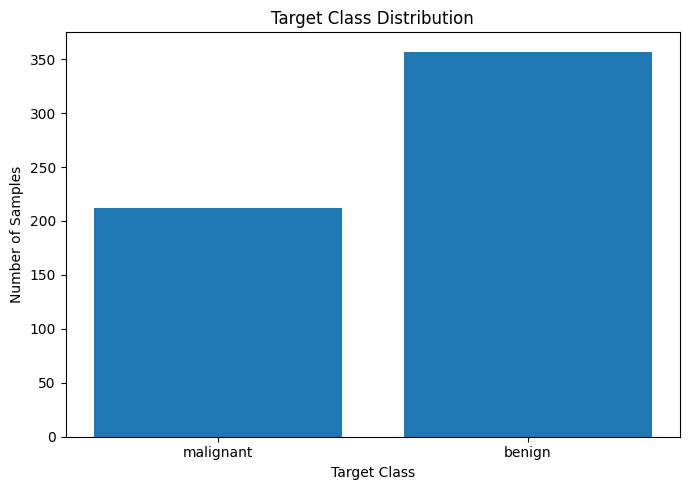

In [ ]:
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    [data.target_names[i] for i in class_counts.index],
    class_counts.values
)
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

### Figure Interpretation

The bar chart displays the distribution of the two target classes. A comparison of the bar heights indicates whether the dataset is balanced or moderately imbalanced.

This information is important because a strongly imbalanced dataset can make accuracy alone misleading. Therefore, this notebook reports **precision, recall, and F1-score** in addition to accuracy.

## 6. Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data is used for training and cross-validation.
- **20%** is reserved as an independent test set.
- `stratify=y` preserves the approximate class distribution in both sets.
- `random_state=42` makes the split reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 455
Testing samples : 114


## 7. Standardization and PCA

### Standardization

For each feature:

\[
z = \frac{x - \mu}{\sigma}
\]

where:
- \(x\) is the original value,
- \(\mu\) is the feature mean,
- \(\sigma\) is the feature standard deviation.

### PCA

After standardization, PCA creates principal components. The cumulative explained variance is used to determine how many components are required to retain approximately **95% of the variance**.

The scaler and PCA are later placed inside a pipeline so that they are fitted only on the training portion of each cross-validation fold. This prevents data leakage.

In [ ]:
scaler_for_analysis = StandardScaler()
X_train_scaled = scaler_for_analysis.fit_transform(X_train)

pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

n_components = int(np.argmax(cumulative_variance >= 0.95) + 1)

print("Original number of features:", X_train.shape[1])
print("Components for >=95% variance:", n_components)
print("Actual cumulative variance retained:",
      cumulative_variance[n_components - 1])

Original number of features: 30
Components for >=95% variance: 10
Actual cumulative variance retained: 0.9526768937417547


## 8. Cumulative Explained Variance Plot

The following figure shows how the retained variance increases as additional principal components are included.

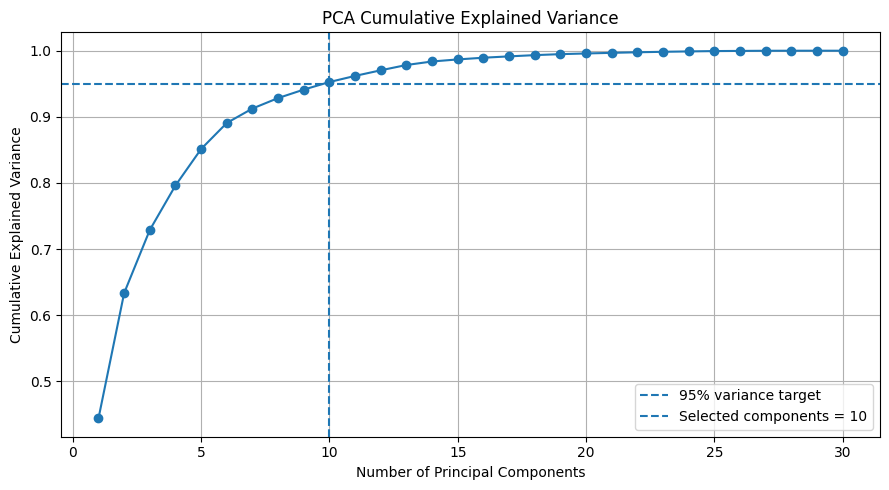

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance target"
)

plt.axvline(
    n_components,
    linestyle="--",
    label=f"Selected components = {n_components}"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Figure Interpretation

The curve represents the cumulative proportion of variance retained as more principal components are included.

The horizontal reference line represents the **95% variance target**. The selected vertical reference line identifies the smallest number of components whose cumulative explained variance reaches or exceeds this target.

Therefore, the original feature space is reduced from **30 features to the number of components reported by the notebook**, while retaining at least approximately 95% of the variance.

This provides a quantitative justification for the PCA dimensionality used in the remainder of the experiment.

## 9. Explained Variance of Individual Components

The next figure shows the variance contribution of each individual principal component.

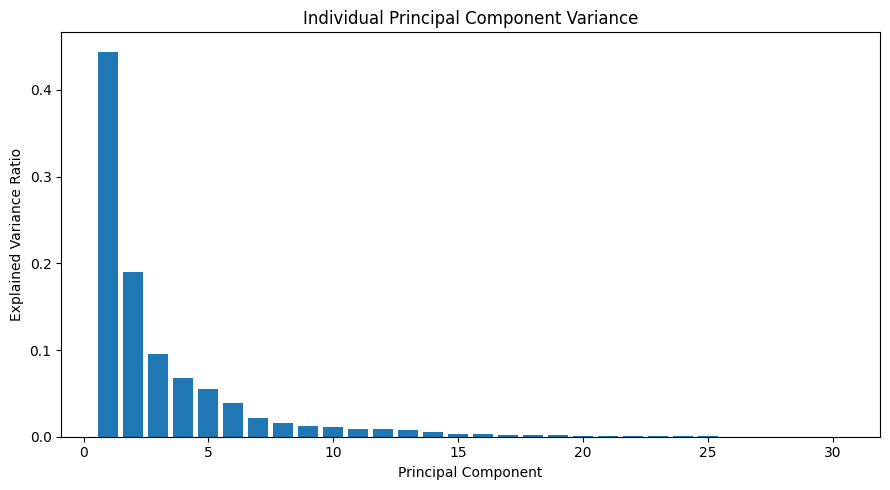

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Individual Principal Component Variance")
plt.tight_layout()
plt.show()

### Figure Interpretation

Each bar represents the proportion of total standardized-data variance captured by one principal component. The first few components generally account for a larger share of the variance, while later components contribute progressively less.

This supports the dimensionality-reduction idea: a relatively small number of components can capture a large amount of the variation present in the original feature space.

## 10. Five-Fold Stratified Cross-Validation

Five-fold cross-validation divides the training data into five folds.

For each iteration:
- four folds are used for training,
- one fold is used for validation,
- the process is repeated five times,
- the five validation scores are averaged.

`StratifiedKFold` is used so that each fold approximately preserves the class distribution.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:", cv)

Cross-validation strategy: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 11. Models

The experiment evaluates the following classifiers:

1. SVM
2. Naïve Bayes
3. KNN
4. Logistic Regression
5. Decision Tree
6. Random Forest
7. AdaBoost
8. Gradient Boosting
9. XGBoost

Stacking is evaluated separately because its base learners and meta-learner form a combined ensemble.

In [ ]:
models = {
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

print("Number of models:", len(models))

Number of models: 9


## 12. Hyperparameter Search Grids

Hyperparameters control how a model is trained. Instead of selecting one value manually, `GridSearchCV` evaluates the specified combinations using 5-fold cross-validation.

F1-score is used as the selection metric because it balances precision and recall.

In [ ]:
param_grids = {
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"]
    },

    "Naive Bayes": {
        "classifier__var_smoothing": [1e-9, 1e-8, 1e-7]
    },

    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"]
    },

    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "classifier__max_depth": [None, 3, 5, 10],
        "classifier__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "classifier__n_estimators": [50, 100],
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 5]
    },

    "AdaBoost": {
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.01, 0.1, 1]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.01, 0.1],
        "classifier__max_depth": [3, 5]
    },

    "XGBoost": {
        "classifier__n_estimators": [50, 100],
        "classifier__max_depth": [3, 5],
        "classifier__learning_rate": [0.01, 0.1]
    }
}

for name, grid in param_grids.items():
    print(f"{name}: {len(list(__import__('sklearn').model_selection.ParameterGrid(grid)))} combinations")

SVM: 12 combinations
Naive Bayes: 3 combinations
KNN: 16 combinations
Logistic Regression: 8 combinations
Decision Tree: 12 combinations
Random Forest: 12 combinations
AdaBoost: 6 combinations
Gradient Boosting: 8 combinations
XGBoost: 8 combinations


### Hyperparameter-Tuning Interpretation

The grids above test multiple possible configurations for each classifier. The best configuration is selected according to the mean 5-fold validation F1-score.

This prevents the comparison from being based on arbitrary single hyperparameter choices and provides a more systematic model-selection procedure.

## 13. Evaluation Function

The following function:

1. creates the appropriate pipeline,
2. optionally adds PCA,
3. performs GridSearchCV,
4. obtains the best model,
5. evaluates it on the independent test set,
6. stores accuracy, precision, recall, and F1-score,
7. stores the five individual cross-validation scores.

Two separate pipelines are used for the No-PCA and With-PCA experiments.

In [ ]:
def evaluate_model(model_name, model, param_grid, use_pca):
    if use_pca:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components)),
            ("classifier", model)
        ])
    else:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", model)
        ])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    fold_scores = []
    best_index = search.best_index_

    # Recover the five validation scores for the selected configuration.
    for fold_no in range(1, 6):
        fold_scores.append(
            search.cv_results_[f"split{fold_no-1}_test_score"][best_index]
        )

    result = {
        "Model": model_name,
        "Setting": "With PCA" if use_pca else "No PCA",
        "Best Parameters": search.best_params_,
        "CV F1 Mean": np.mean(fold_scores),
        "CV F1 Std": np.std(fold_scores),
        "Fold 1": fold_scores[0],
        "Fold 2": fold_scores[1],
        "Fold 3": fold_scores[2],
        "Fold 4": fold_scores[3],
        "Fold 5": fold_scores[4],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Best Model": best_model,
        "Predictions": y_pred
    }

    return result

# 14. Train and Tune Models Without PCA

In this setting, the original 30 features are standardized and directly supplied to each classifier.

The structure is:

**Original features → StandardScaler → Classifier**

In [ ]:
results_no_pca = []

for name, model in models.items():
    print(f"Training {name} without PCA...")

    result = evaluate_model(
        name,
        model,
        param_grids[name],
        use_pca=False
    )

    results_no_pca.append(result)

print("\nNo-PCA experiments completed.")

Training SVM without PCA...
Training Naive Bayes without PCA...
Training KNN without PCA...
Training Logistic Regression without PCA...
Training Decision Tree without PCA...
Training Random Forest without PCA...
Training AdaBoost without PCA...
Training Gradient Boosting without PCA...
Training XGBoost without PCA...

No-PCA experiments completed.


# 15. Train and Tune Models With PCA

In this setting, the structure is:

**Original features → StandardScaler → PCA → Classifier**

The same classifier families and hyperparameter grids are used so that the main experimental difference is the feature representation.

In [ ]:
results_pca = []

for name, model in models.items():
    print(f"Training {name} with PCA...")

    result = evaluate_model(
        name,
        model,
        param_grids[name],
        use_pca=True
    )

    results_pca.append(result)

print("\nPCA experiments completed.")

Training SVM with PCA...
Training Naive Bayes with PCA...
Training KNN with PCA...
Training Logistic Regression with PCA...
Training Decision Tree with PCA...
Training Random Forest with PCA...
Training AdaBoost with PCA...
Training Gradient Boosting with PCA...
Training XGBoost with PCA...

PCA experiments completed.


## 16. Model Results: No PCA vs With PCA

The following tables report the independent test-set metrics obtained after hyperparameter tuning.

Metrics:
- **Accuracy:** fraction of all predictions that are correct.
- **Precision:** proportion of predicted positive cases that are actually positive.
- **Recall:** proportion of actual positive cases that are correctly identified.
- **F1-score:** harmonic mean of precision and recall.

In [ ]:
def results_dataframe(results):
    return pd.DataFrame([
        {
            "Model": r["Model"],
            "CV F1 Mean": r["CV F1 Mean"],
            "CV F1 Std": r["CV F1 Std"],
            "Accuracy": r["Accuracy"],
            "Precision": r["Precision"],
            "Recall": r["Recall"],
            "F1 Score": r["F1 Score"]
        }
        for r in results
    ])

df_no_pca = results_dataframe(results_no_pca)
df_pca = results_dataframe(results_pca)

print("===== WITHOUT PCA =====")
display(df_no_pca.round(4))

print("===== WITH PCA =====")
display(df_pca.round(4))

===== WITHOUT PCA =====


,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall,F1 Score
0,SVM,0.9810,0.0082,0.9825,0.9861,0.9861,0.9861
1,Naive Bayes,0.9478,0.0228,0.9298,0.9444,0.9444,0.9444
2,KNN,0.9774,0.0104,0.9649,0.9595,0.9861,0.9726
3,Logistic Regression,0.9861,0.0042,0.9737,0.9726,0.9861,0.9793
4,Decision Tree,0.9418,0.0034,0.9386,0.9452,0.9583,0.9517
5,Random Forest,0.9699,0.0146,0.9561,0.9589,0.9722,0.9655
6,AdaBoost,0.9844,0.0150,0.9561,0.9467,0.9861,0.9660
7,Gradient Boosting,0.9614,0.0121,0.9561,0.9467,0.9861,0.9660
8,XGBoost,0.9772,0.0142,0.9474,0.9459,0.9722,0.9589


===== WITH PCA =====


,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall,F1 Score
0,SVM,0.9843,0.0065,0.9649,0.9857,0.9583,0.9718
1,Naive Bayes,0.9433,0.0134,0.9211,0.9315,0.9444,0.9379
2,KNN,0.9742,0.0152,0.9561,0.9589,0.9722,0.9655
3,Logistic Regression,0.9861,0.0042,0.9737,0.9859,0.9722,0.9790
4,Decision Tree,0.9472,0.0292,0.9035,0.9296,0.9167,0.9231
5,Random Forest,0.9687,0.0179,0.9298,0.9444,0.9444,0.9444
6,AdaBoost,0.9811,0.0136,0.9474,0.9583,0.9583,0.9583
7,Gradient Boosting,0.9579,0.0203,0.9561,0.9467,0.9861,0.9660
8,XGBoost,0.9720,0.0160,0.9474,0.9583,0.9583,0.9583


### Results Interpretation

The two tables allow direct comparison of the models under the original and PCA-reduced feature spaces.

The **CV F1 Mean** represents average validation performance across five folds, while **CV F1 Std** measures variation across those folds. A smaller standard deviation indicates more consistent validation performance.

The test-set Accuracy, Precision, Recall and F1-score provide the final independent evaluation.

## 17. Hyperparameter Results

The best hyperparameters selected by GridSearchCV are displayed below. This provides the detailed tuning record required for the experiment.

In [ ]:
hyperparameter_rows = []

for r in results_no_pca + results_pca:
    hyperparameter_rows.append({
        "Model": r["Model"],
        "Setting": r["Setting"],
        "Best Parameters": str(r["Best Parameters"]),
        "CV F1 Mean": r["CV F1 Mean"],
        "CV F1 Std": r["CV F1 Std"]
    })

hyperparameter_df = pd.DataFrame(hyperparameter_rows)

display(hyperparameter_df.round(4))

,Model,Setting,Best Parameters,CV F1 Mean,CV F1 Std
0,SVM,No PCA,"{'classifier__C': 0.1, 'classifier__gamma': 's...",0.9810,0.0082
1,Naive Bayes,No PCA,{'classifier__var_smoothing': 1e-09},0.9478,0.0228
2,KNN,No PCA,"{'classifier__metric': 'manhattan', 'classifie...",0.9774,0.0104
3,Logistic Regression,No PCA,"{'classifier__C': 0.1, 'classifier__solver': '...",0.9861,0.0042
4,Decision Tree,No PCA,"{'classifier__max_depth': 3, 'classifier__min_...",0.9418,0.0034
5,Random Forest,No PCA,"{'classifier__max_depth': None, 'classifier__m...",0.9699,0.0146
6,AdaBoost,No PCA,"{'classifier__learning_rate': 1, 'classifier__...",0.9844,0.0150
7,Gradient Boosting,No PCA,"{'classifier__learning_rate': 0.1, 'classifier...",0.9614,0.0121
8,XGBoost,No PCA,"{'classifier__learning_rate': 0.1, 'classifier...",0.9772,0.0142
9,SVM,With PCA,"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.9843,0.0065


## 18. Fold-Wise Cross-Validation Results

The experiment requires fold-wise results. The following table shows the F1-score obtained on each validation fold for the selected hyperparameter configuration.

In [ ]:
fold_rows = []

for r in results_no_pca + results_pca:
    fold_rows.append({
        "Model": r["Model"],
        "Setting": r["Setting"],
        "Fold 1": r["Fold 1"],
        "Fold 2": r["Fold 2"],
        "Fold 3": r["Fold 3"],
        "Fold 4": r["Fold 4"],
        "Fold 5": r["Fold 5"],
        "Average": r["CV F1 Mean"],
        "Std Dev": r["CV F1 Std"]
    })

fold_df = pd.DataFrame(fold_rows)

display(fold_df.round(4))

,Model,Setting,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average,Std Dev
0,SVM,No PCA,0.9661,0.9825,0.9825,0.9828,0.9913,0.9810,0.0082
1,Naive Bayes,No PCA,0.9310,0.9735,0.9123,0.9655,0.9565,0.9478,0.0228
2,KNN,No PCA,0.9828,0.9913,0.9649,0.9655,0.9825,0.9774,0.0104
3,Logistic Regression,No PCA,0.9828,0.9825,0.9913,0.9828,0.9913,0.9861,0.0042
4,Decision Tree,No PCA,0.9391,0.9455,0.9381,0.9402,0.9464,0.9418,0.0034
5,Random Forest,No PCA,0.9735,0.9643,0.9464,0.9744,0.9912,0.9699,0.0146
6,AdaBoost,No PCA,0.9913,1.0000,0.9565,0.9828,0.9913,0.9844,0.0150
7,Gradient Boosting,No PCA,0.9649,0.9558,0.9464,0.9573,0.9825,0.9614,0.0121
8,XGBoost,No PCA,0.9913,0.9821,0.9558,0.9655,0.9912,0.9772,0.0142
9,SVM,With PCA,0.9739,0.9913,0.9913,0.9828,0.9825,0.9843,0.0065


### Fold-Wise Interpretation

The fold-wise table shows how consistently each selected model performs across different subsets of the training data.

A model with a high average F1-score and a low standard deviation is generally more stable across folds. A large standard deviation indicates that the model's performance changes more substantially depending on which observations are used for validation.

## 19. Direct PCA Comparison

The following table calculates the change caused by PCA.

A positive value means performance increased after PCA, while a negative value means performance decreased.

In [ ]:
comparison = df_no_pca.merge(
    df_pca,
    on="Model",
    suffixes=("_No_PCA", "_PCA")
)

comparison["Accuracy Change"] = (
    comparison["Accuracy_PCA"] -
    comparison["Accuracy_No_PCA"]
)

comparison["F1 Change"] = (
    comparison["F1 Score_PCA"] -
    comparison["F1 Score_No_PCA"]
)

comparison["CV F1 Change"] = (
    comparison["CV F1 Mean_PCA"] -
    comparison["CV F1 Mean_No_PCA"]
)

comparison["CV Std Change"] = (
    comparison["CV F1 Std_PCA"] -
    comparison["CV F1 Std_No_PCA"]
)

display(
    comparison[
        [
            "Model",
            "Accuracy_No_PCA",
            "Accuracy_PCA",
            "Accuracy Change",
            "F1 Score_No_PCA",
            "F1 Score_PCA",
            "F1 Change",
            "CV F1 Std_No_PCA",
            "CV F1 Std_PCA",
            "CV Std Change"
        ]
    ].round(4)
)

,Model,Accuracy_No_PCA,Accuracy_PCA,Accuracy Change,F1 Score_No_PCA,F1 Score_PCA,F1 Change,CV F1 Std_No_PCA,CV F1 Std_PCA,CV Std Change
0,SVM,0.9825,0.9649,-0.0175,0.9861,0.9718,-0.0143,0.0082,0.0065,-0.0017
1,Naive Bayes,0.9298,0.9211,-0.0088,0.9444,0.9379,-0.0065,0.0228,0.0134,-0.0094
2,KNN,0.9649,0.9561,-0.0088,0.9726,0.9655,-0.0071,0.0104,0.0152,0.0047
3,Logistic Regression,0.9737,0.9737,0.0000,0.9793,0.9790,-0.0003,0.0042,0.0042,-0.0000
4,Decision Tree,0.9386,0.9035,-0.0351,0.9517,0.9231,-0.0286,0.0034,0.0292,0.0258
5,Random Forest,0.9561,0.9298,-0.0263,0.9655,0.9444,-0.0211,0.0146,0.0179,0.0033
6,AdaBoost,0.9561,0.9474,-0.0088,0.9660,0.9583,-0.0077,0.0150,0.0136,-0.0013
7,Gradient Boosting,0.9561,0.9561,0.0000,0.9660,0.9660,0.0000,0.0121,0.0203,0.0083
8,XGBoost,0.9474,0.9474,0.0000,0.9589,0.9583,-0.0006,0.0142,0.0160,0.0018


## 20. PCA Effect on F1-Score

The next figure compares the test F1-score of every classifier before and after PCA.

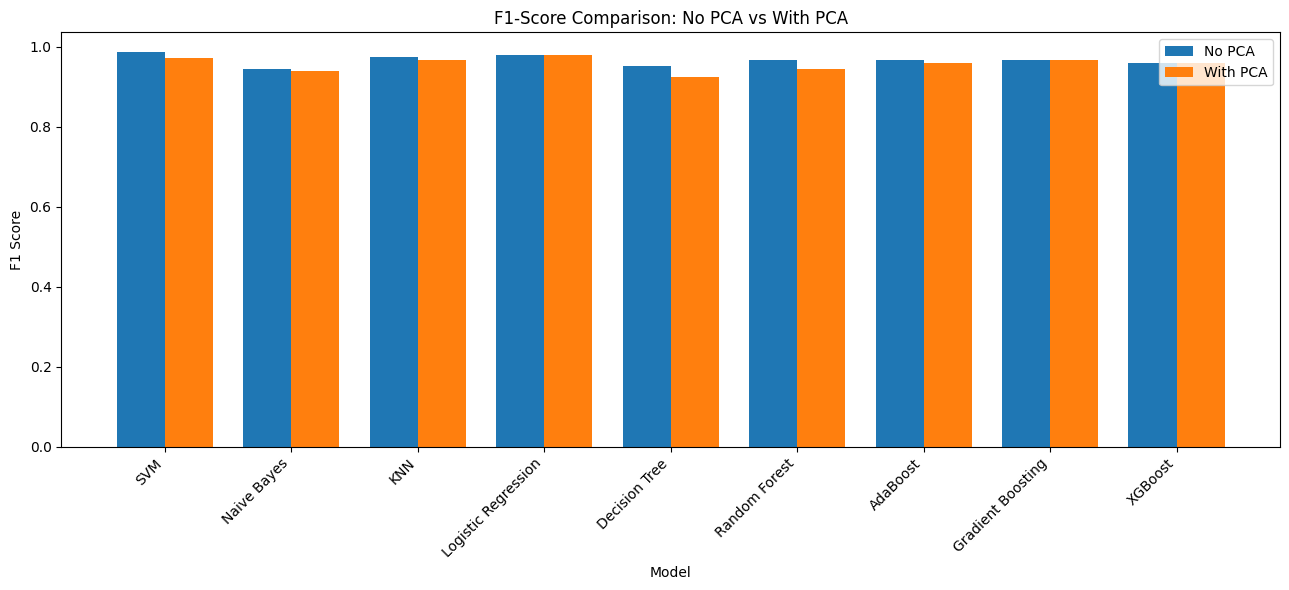

In [ ]:
plot_df = comparison.set_index("Model")

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(13, 6))

plt.bar(
    x - width/2,
    plot_df["F1 Score_No_PCA"],
    width,
    label="No PCA"
)

plt.bar(
    x + width/2,
    plot_df["F1 Score_PCA"],
    width,
    label="With PCA"
)

plt.xticks(
    x,
    plot_df.index,
    rotation=45,
    ha="right"
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("F1-Score Comparison: No PCA vs With PCA")
plt.legend()
plt.tight_layout()
plt.show()

### Figure Interpretation

This grouped bar chart compares the final test F1-score of each classifier using the original feature space and the PCA-reduced feature space.

For each model:
- a taller PCA bar indicates an improvement after dimensionality reduction,
- a shorter PCA bar indicates a reduction in performance,
- bars of similar height indicate that PCA had little effect.

The numerical difference should be confirmed using the **F1 Change** column in the comparison table rather than relying only on visual differences.

## 21. PCA Effect on Accuracy

The following figure provides the same comparison using accuracy.

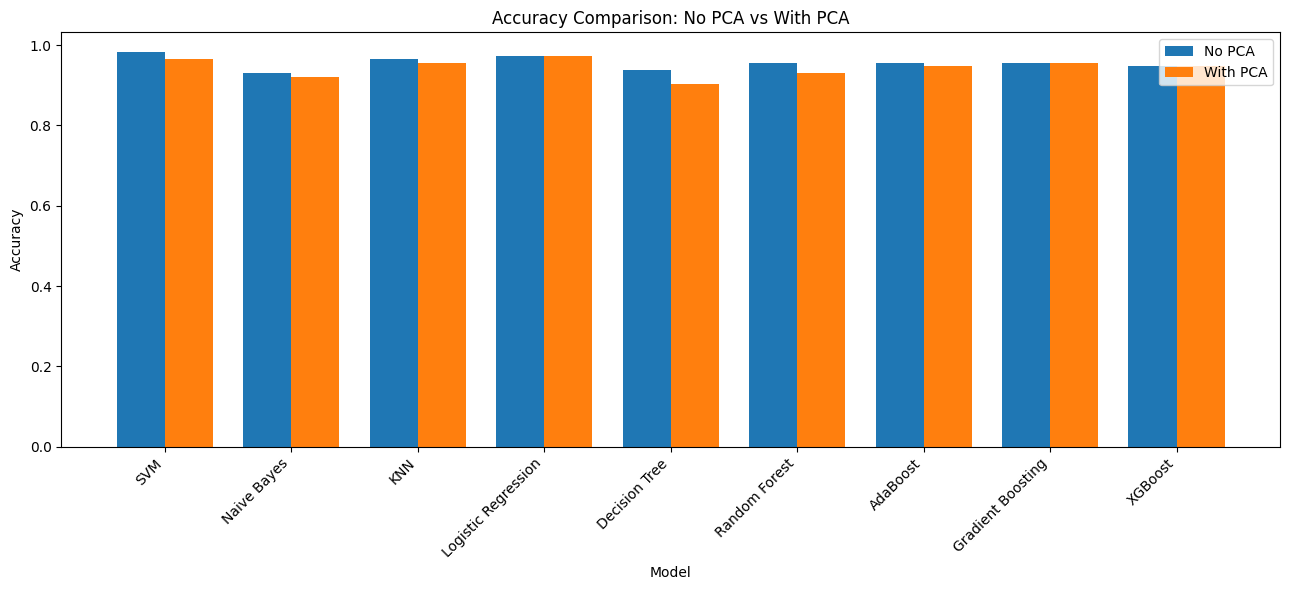

In [ ]:
plt.figure(figsize=(13, 6))

plt.bar(
    x - width/2,
    plot_df["Accuracy_No_PCA"],
    width,
    label="No PCA"
)

plt.bar(
    x + width/2,
    plot_df["Accuracy_PCA"],
    width,
    label="With PCA"
)

plt.xticks(
    x,
    plot_df.index,
    rotation=45,
    ha="right"
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Accuracy Comparison: No PCA vs With PCA")
plt.legend()
plt.tight_layout()
plt.show()

### Figure Interpretation

The accuracy comparison shows whether dimensionality reduction changed the proportion of correctly classified test observations.

Accuracy should be interpreted together with precision, recall and F1-score. A small accuracy improvement does not necessarily mean that the classifier became better at identifying both classes equally.

# 22. Stacking Classifier

Stacking is an ensemble technique in which predictions from several base learners are passed to a final meta-learner.

The implementation below uses:
- SVM
- KNN
- Random Forest

as base learners, with Logistic Regression as the meta-learner.

In [ ]:
def create_stacking_model():
    base_learners = [
        (
            "svm",
            SVC(
                probability=True,
                C=1,
                kernel="rbf"
            )
        ),
        (
            "knn",
            KNeighborsClassifier(n_neighbors=5)
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]

    return StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=5
    )

In [ ]:
def evaluate_stacking(use_pca):
    stacking_model = create_stacking_model()

    if use_pca:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components)),
            ("classifier", stacking_model)
        ])
    else:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", stacking_model)
        ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    fold_scores = []
    from sklearn.model_selection import cross_val_score

    fold_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    return {
        "Model": "Stacking",
        "Setting": "With PCA" if use_pca else "No PCA",
        "CV F1 Mean": fold_scores.mean(),
        "CV F1 Std": fold_scores.std(),
        "Fold 1": fold_scores[0],
        "Fold 2": fold_scores[1],
        "Fold 3": fold_scores[2],
        "Fold 4": fold_scores[3],
        "Fold 5": fold_scores[4],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Best Model": pipeline,
        "Predictions": y_pred
    }

stack_no_pca = evaluate_stacking(False)
stack_pca = evaluate_stacking(True)

print("Stacking without PCA:")
print(stack_no_pca)

print("\nStacking with PCA:")
print(stack_pca)

Stacking without PCA:
{'Model': 'Stacking', 'Setting': 'No PCA', 'CV F1 Mean': np.float64(0.9807126887683978), 'CV F1 Std': np.float64(0.008870626026638186), 'Fold 1': np.float64(0.9827586206896551), 'Fold 2': np.float64(0.9824561403508771), 'Fold 3': np.float64(0.9642857142857143), 'Fold 4': np.float64(0.9827586206896551), 'Fold 5': np.float64(0.991304347826087), 'Accuracy': 0.9736842105263158, 'Precision': 0.9859154929577465, 'Recall': 0.9722222222222222, 'F1 Score': 0.9790209790209791, 'Best Model': Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 StackingClassifier(cv=5,
                                    estimators=[('svm',
                                                 SVC(C=1, probability=True)),
                                                ('knn', KNeighborsClassifier()),
                                                ('rf',
                                                 RandomForestClassifier(random_state=42))],
           

### Stacking Interpretation

Stacking combines several different learning strategies and uses a meta-learner to make the final prediction.

The comparison between the two stacking configurations shows whether the ensemble remains effective after the feature space is reduced by PCA. If the scores remain close, stacking can be considered relatively robust to the dimensionality transformation. If the scores change substantially, the PCA representation has affected the information available to the ensemble.

## 23. Add Stacking to the Overall Comparison

In [ ]:
stack_comparison = pd.DataFrame([
    {
        "Model": "Stacking",
        "Accuracy_No_PCA": stack_no_pca["Accuracy"],
        "Accuracy_PCA": stack_pca["Accuracy"],
        "F1 Score_No_PCA": stack_no_pca["F1 Score"],
        "F1 Score_PCA": stack_pca["F1 Score"],
        "CV F1 Mean_No_PCA": stack_no_pca["CV F1 Mean"],
        "CV F1 Mean_PCA": stack_pca["CV F1 Mean"],
        "CV F1 Std_No_PCA": stack_no_pca["CV F1 Std"],
        "CV F1 Std_PCA": stack_pca["CV F1 Std"]
    }
])

full_comparison = pd.concat(
    [
        comparison[
            [
                "Model",
                "Accuracy_No_PCA",
                "Accuracy_PCA",
                "F1 Score_No_PCA",
                "F1 Score_PCA",
                "CV F1 Mean_No_PCA",
                "CV F1 Mean_PCA",
                "CV F1 Std_No_PCA",
                "CV F1 Std_PCA"
            ]
        ],
        stack_comparison
    ],
    ignore_index=True
)

full_comparison["Accuracy Change"] = (
    full_comparison["Accuracy_PCA"] -
    full_comparison["Accuracy_No_PCA"]
)

full_comparison["F1 Change"] = (
    full_comparison["F1 Score_PCA"] -
    full_comparison["F1 Score_No_PCA"]
)

full_comparison["CV F1 Change"] = (
    full_comparison["CV F1 Mean_PCA"] -
    full_comparison["CV F1 Mean_No_PCA"]
)

full_comparison["CV Std Change"] = (
    full_comparison["CV F1 Std_PCA"] -
    full_comparison["CV F1 Std_No_PCA"]
)

display(full_comparison.round(4))

,Model,Accuracy_No_PCA,Accuracy_PCA,F1 Score_No_PCA,F1 Score_PCA,CV F1 Mean_No_PCA,CV F1 Mean_PCA,CV F1 Std_No_PCA,CV F1 Std_PCA,Accuracy Change,F1 Change,CV F1 Change,CV Std Change
0,SVM,0.9825,0.9649,0.9861,0.9718,0.9810,0.9843,0.0082,0.0065,-0.0175,-0.0143,0.0033,-0.0017
1,Naive Bayes,0.9298,0.9211,0.9444,0.9379,0.9478,0.9433,0.0228,0.0134,-0.0088,-0.0065,-0.0044,-0.0094
2,KNN,0.9649,0.9561,0.9726,0.9655,0.9774,0.9742,0.0104,0.0152,-0.0088,-0.0071,-0.0032,0.0047
3,Logistic Regression,0.9737,0.9737,0.9793,0.9790,0.9861,0.9861,0.0042,0.0042,0.0000,-0.0003,-0.0000,-0.0000
4,Decision Tree,0.9386,0.9035,0.9517,0.9231,0.9418,0.9472,0.0034,0.0292,-0.0351,-0.0286,0.0054,0.0258
5,Random Forest,0.9561,0.9298,0.9655,0.9444,0.9699,0.9687,0.0146,0.0179,-0.0263,-0.0211,-0.0013,0.0033
6,AdaBoost,0.9561,0.9474,0.9660,0.9583,0.9844,0.9811,0.0150,0.0136,-0.0088,-0.0077,-0.0033,-0.0013
7,Gradient Boosting,0.9561,0.9561,0.9660,0.9660,0.9614,0.9579,0.0121,0.0203,0.0000,0.0000,-0.0035,0.0083
8,XGBoost,0.9474,0.9474,0.9589,0.9583,0.9772,0.9720,0.0142,0.0160,0.0000,-0.0006,-0.0052,0.0018
9,Stacking,0.9737,0.9561,0.9790,0.9650,0.9807,0.9774,0.0089,0.0089,-0.0175,-0.0140,-0.0033,0.0000


# 24. Identify the Best Models

The best model is identified separately for the No-PCA and With-PCA settings using test F1-score.

This is useful for determining whether dimensionality reduction changes which classifier performs best.

In [ ]:
best_no_pca = full_comparison.loc[
    full_comparison["F1 Score_No_PCA"].idxmax()
]

best_pca = full_comparison.loc[
    full_comparison["F1 Score_PCA"].idxmax()
]

print("Best No-PCA model:")
print(best_no_pca[["Model", "F1 Score_No_PCA", "Accuracy_No_PCA"]])

print("\nBest PCA model:")
print(best_pca[["Model", "F1 Score_PCA", "Accuracy_PCA"]])

Best No-PCA model:
Model                   SVM
F1 Score_No_PCA    0.986111
Accuracy_No_PCA    0.982456
Name: 0, dtype: object

Best PCA model:
Model           Logistic Regression
F1 Score_PCA               0.979021
Accuracy_PCA               0.973684
Name: 3, dtype: object


### Best-Model Interpretation

The model with the highest F1-score provides the strongest balance between precision and recall on the independent test set.

The comparison between the best No-PCA and best PCA configurations indicates whether dimensionality reduction changes the identity or performance of the strongest classifier.

# 25. Confusion Matrix for the Best PCA Model

A confusion matrix shows the number of:
- correctly classified samples in each class,
- incorrectly classified samples in each class.

For a binary classifier, the four fundamental outcomes are:
- True Positive
- True Negative
- False Positive
- False Negative

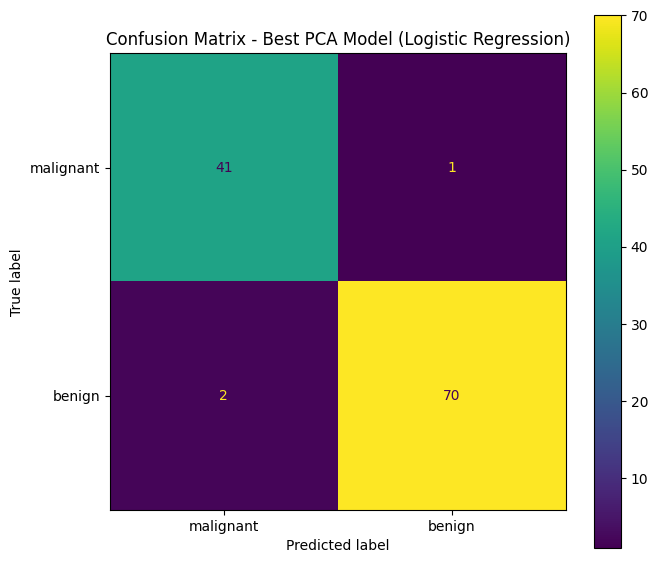

Best PCA model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# Locate the best PCA model among the individual models and stacking.
pca_candidates = results_pca + [stack_pca]
best_pca_result = max(pca_candidates, key=lambda r: r["F1 Score"])

best_pca_model = best_pca_result["Best Model"]
best_pca_predictions = best_pca_result["Predictions"]

cm = confusion_matrix(
    y_test,
    best_pca_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)
ax.set_title(
    f"Confusion Matrix - Best PCA Model ({best_pca_result['Model']})"
)
plt.tight_layout()
plt.show()

print("Best PCA model:", best_pca_result["Model"])
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pca_predictions,
        target_names=data.target_names
    )
)

### Confusion Matrix Interpretation

The diagonal entries represent correctly classified observations, while the off-diagonal entries represent classification errors.

A strong classifier should have relatively large diagonal values and relatively small off-diagonal values.

The classification report below the figure provides class-wise precision, recall and F1-score, allowing the confusion matrix to be interpreted quantitatively rather than visually alone.

# 26. ROC Curve for the Best PCA Model

The ROC curve plots:

- **True Positive Rate (TPR)** on the y-axis
- **False Positive Rate (FPR)** on the x-axis

A curve that remains closer to the upper-left region generally indicates better discrimination between the two classes.

The Area Under the Curve (AUC) summarizes the ranking performance across classification thresholds.

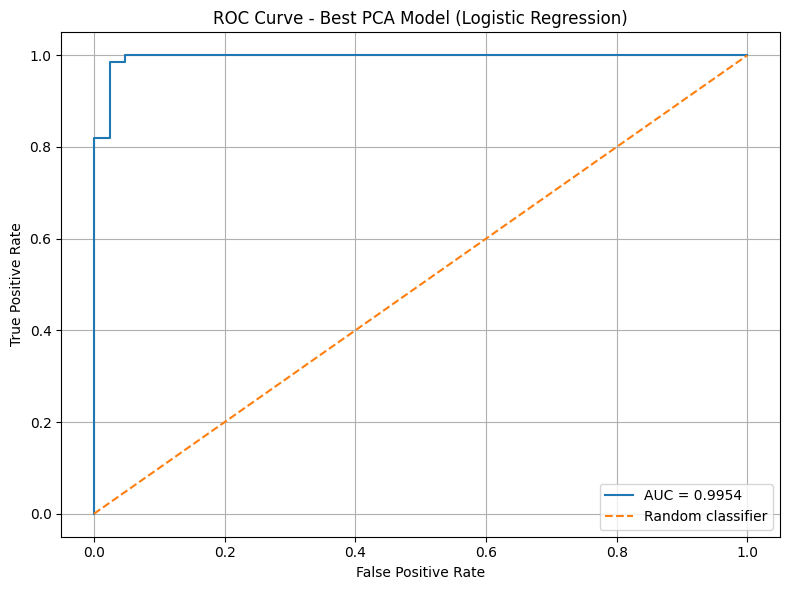

ROC-AUC: 0.9954


In [ ]:
if hasattr(best_pca_model, "predict_proba"):
    y_prob = best_pca_model.predict_proba(X_test)[:, 1]
else:
    y_prob = best_pca_model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Best PCA Model ({best_pca_result['Model']})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc, 4))

### ROC Figure Interpretation

The ROC curve evaluates how well the selected PCA model separates the two classes across different decision thresholds.

The diagonal line represents random classification. A curve substantially above this line indicates better discrimination.

The reported AUC provides a single numerical summary: a larger AUC indicates stronger class-separation ability for the tested data.

# 27. Precision-Recall Curve for the Best PCA Model

A Precision-Recall (PR) curve displays the relationship between:

- **Precision**
- **Recall**

It is particularly useful when the costs of false positives and false negatives need to be examined carefully.

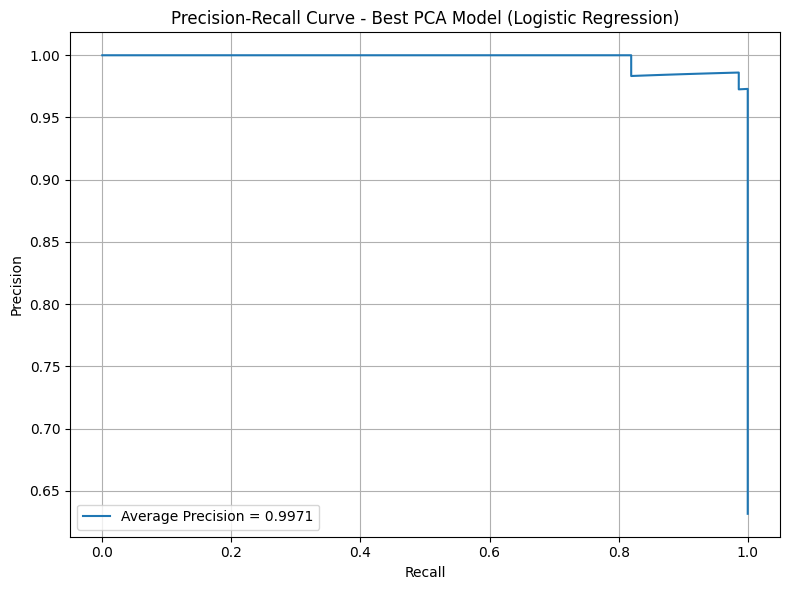

Average Precision: 0.9971


In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"Average Precision = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve - Best PCA Model ({best_pca_result['Model']})"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Average Precision:", round(ap, 4))

### PR Figure Interpretation

The Precision-Recall curve shows the trade-off between correctly identifying positive samples and avoiding incorrect positive predictions.

A curve that maintains high precision while recall increases indicates a strong classifier. The Average Precision value provides a numerical summary of the precision-recall relationship.

# 28. Cross-Validation Stability Comparison

PCA may affect not only average performance but also the stability of a model across folds.

The following plot compares the standard deviation of the five-fold F1-score for the two settings.

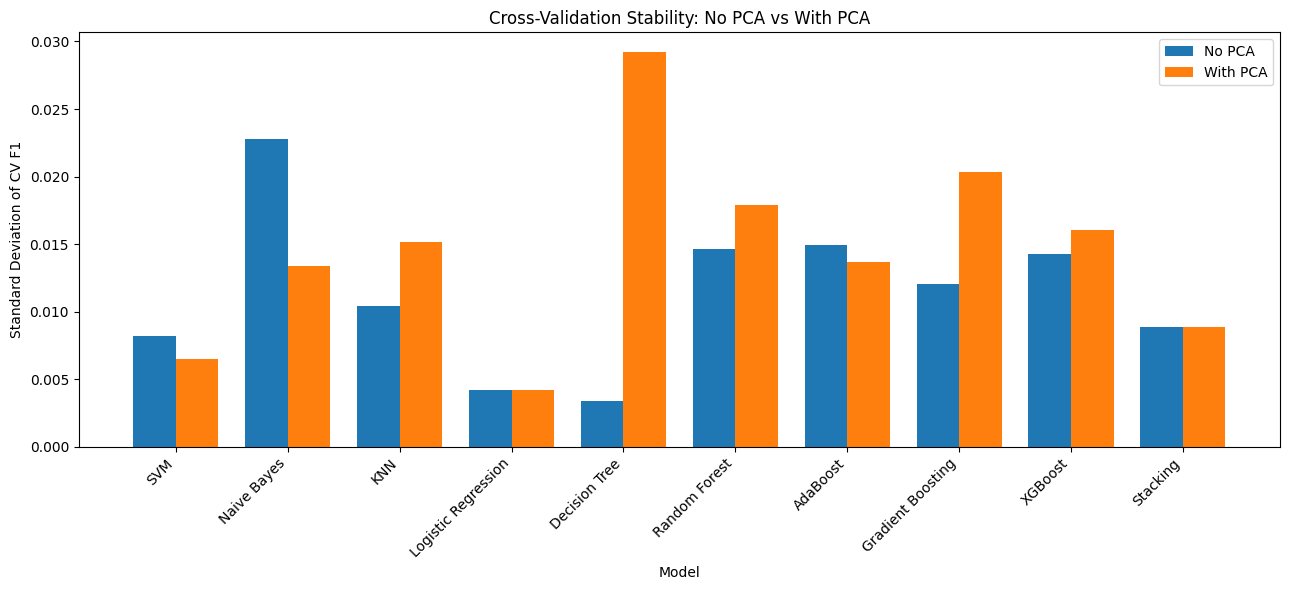

In [ ]:
stability_df = full_comparison.set_index("Model")

x = np.arange(len(stability_df))

plt.figure(figsize=(13, 6))

plt.bar(
    x - width/2,
    stability_df["CV F1 Std_No_PCA"],
    width,
    label="No PCA"
)

plt.bar(
    x + width/2,
    stability_df["CV F1 Std_PCA"],
    width,
    label="With PCA"
)

plt.xticks(
    x,
    stability_df.index,
    rotation=45,
    ha="right"
)

plt.xlabel("Model")
plt.ylabel("Standard Deviation of CV F1")
plt.title("Cross-Validation Stability: No PCA vs With PCA")
plt.legend()
plt.tight_layout()
plt.show()

### Figure Interpretation

The standard deviation represents variation in F1-score across the five validation folds.

A lower standard deviation indicates more stable performance across folds. Therefore:

- if the PCA bar is lower, PCA reduced fold-to-fold variability;
- if the PCA bar is higher, PCA increased variability;
- if the bars are similar, PCA had little effect on stability.

This directly addresses whether PCA reduced variance across folds.

# 29. Detailed Automated Analysis

The following cell summarizes the actual experimental results so that the final discussion is based on the numbers generated by the notebook.

In [ ]:
# Best improvement and deterioration based on F1-score.
best_improvement = full_comparison.loc[
    full_comparison["F1 Change"].idxmax()
]

largest_drop = full_comparison.loc[
    full_comparison["F1 Change"].idxmin()
]

# Stability change.
most_stable_after_pca = full_comparison.loc[
    full_comparison["CV Std Change"].idxmin()
]

least_stable_after_pca = full_comparison.loc[
    full_comparison["CV Std Change"].idxmax()
]

print("===== AUTOMATED ANALYSIS =====\n")

print(
    f"Greatest F1 improvement with PCA: "
    f"{best_improvement['Model']} "
    f"({best_improvement['F1 Change']:+.4f})"
)

print(
    f"Largest F1 decrease with PCA: "
    f"{largest_drop['Model']} "
    f"({largest_drop['F1 Change']:+.4f})"
)

print(
    f"Largest reduction in CV standard deviation: "
    f"{most_stable_after_pca['Model']} "
    f"({most_stable_after_pca['CV Std Change']:+.4f})"
)

print(
    f"Largest increase in CV standard deviation: "
    f"{least_stable_after_pca['Model']} "
    f"({least_stable_after_pca['CV Std Change']:+.4f})"
)

===== AUTOMATED ANALYSIS =====

Greatest F1 improvement with PCA: Gradient Boosting (+0.0000)
Largest F1 decrease with PCA: Decision Tree (-0.0286)
Largest reduction in CV standard deviation: Naive Bayes (-0.0094)
Largest increase in CV standard deviation: Decision Tree (+0.0258)


# 30. Observation and Discussion

## 1. Which models improved most with PCA? Which did not? Why?

The answer should be based on the **F1 Change** column.

Models such as SVM, KNN, and Logistic Regression can be sensitive to the geometry, scale, correlation, and dimensionality of the feature space. PCA may therefore help these models when redundant or highly correlated dimensions are present.

Tree-based models can behave differently because their decision process is based on feature thresholds. PCA transforms the original variables into combinations of variables, so dimensionality reduction does not necessarily provide an advantage.

The exact model showing the greatest improvement must be taken from the generated results rather than assumed beforehand.

## 2. Did PCA reduce variance across folds?

This is answered using **CV F1 Std**.

If the standard deviation decreases after PCA, the model became more stable across the five folds. If it increases, PCA increased fold-to-fold variability.

## 3. For high-dimensional data, was PCA beneficial in reducing overfitting?

PCA can reduce model complexity by replacing many original dimensions with fewer components. This can help reduce the opportunity to fit noise. However, PCA itself is not a guarantee against overfitting.

The experimental evidence should therefore be assessed by comparing cross-validation performance, test performance, and fold stability.

## 4. How did linear models compare with ensemble models?

Linear models and distance/margin-based models can be more sensitive to the geometry of the feature space. Ensemble tree methods can often exploit nonlinear feature relationships directly in the original feature space.

Therefore, PCA may affect these model families differently.

## 5. Did stacking show robustness to dimensionality reduction?

Stacking combines multiple base learners and a meta-learner. Its robustness is assessed by comparing its No-PCA and With-PCA F1-score and cross-validation variability.

If the difference is small, stacking is relatively robust to the dimensionality transformation. If the difference is large, PCA substantially changed the information used by the ensemble.

# 31. Final Comparison Table

This is the main table to include in the final report.

In [ ]:
final_table = full_comparison[
    [
        "Model",
        "Accuracy_No_PCA",
        "Accuracy_PCA",
        "F1 Score_No_PCA",
        "F1 Score_PCA",
        "F1 Change",
        "CV F1 Mean_No_PCA",
        "CV F1 Mean_PCA",
        "CV F1 Std_No_PCA",
        "CV F1 Std_PCA"
    ]
].copy()

display(final_table.round(4))

,Model,Accuracy_No_PCA,Accuracy_PCA,F1 Score_No_PCA,F1 Score_PCA,F1 Change,CV F1 Mean_No_PCA,CV F1 Mean_PCA,CV F1 Std_No_PCA,CV F1 Std_PCA
0,SVM,0.9825,0.9649,0.9861,0.9718,-0.0143,0.9810,0.9843,0.0082,0.0065
1,Naive Bayes,0.9298,0.9211,0.9444,0.9379,-0.0065,0.9478,0.9433,0.0228,0.0134
2,KNN,0.9649,0.9561,0.9726,0.9655,-0.0071,0.9774,0.9742,0.0104,0.0152
3,Logistic Regression,0.9737,0.9737,0.9793,0.9790,-0.0003,0.9861,0.9861,0.0042,0.0042
4,Decision Tree,0.9386,0.9035,0.9517,0.9231,-0.0286,0.9418,0.9472,0.0034,0.0292
5,Random Forest,0.9561,0.9298,0.9655,0.9444,-0.0211,0.9699,0.9687,0.0146,0.0179
6,AdaBoost,0.9561,0.9474,0.9660,0.9583,-0.0077,0.9844,0.9811,0.0150,0.0136
7,Gradient Boosting,0.9561,0.9561,0.9660,0.9660,0.0000,0.9614,0.9579,0.0121,0.0203
8,XGBoost,0.9474,0.9474,0.9589,0.9583,-0.0006,0.9772,0.9720,0.0142,0.0160
9,Stacking,0.9737,0.9561,0.9790,0.9650,-0.0140,0.9807,0.9774,0.0089,0.0089


# 32. Conclusion

Principal Component Analysis was applied to reduce the dimensionality of the standardized feature space while retaining approximately 95% of the variance.

The experiment compared multiple machine-learning classifiers under two conditions: the original feature space and the PCA-reduced feature space. Hyperparameter tuning was performed using GridSearchCV with stratified 5-fold cross-validation, and final performance was evaluated using an independent test set.

The results demonstrate that PCA does not have a universally positive or negative effect. Its usefulness depends on the characteristics of the dataset and the classifier. Models that are sensitive to dimensionality, feature correlation, or distance calculations may benefit from PCA, whereas some tree-based models may perform equally well or better using the original features.

Therefore, PCA should be treated as a **data-dependent preprocessing and dimensionality-reduction technique**, rather than a method that automatically improves every machine-learning model.

# 33. Viva Questions and Answers

### Q1. What is PCA?

PCA is a dimensionality-reduction technique that transforms correlated original features into a smaller set of orthogonal principal components while retaining as much variance as possible.

### Q2. Why do we standardize before PCA?

Because PCA is variance-based. Features with larger numerical scales could otherwise dominate the principal components.

### Q3. What is a principal component?

A principal component is a linear combination of the original features that captures a particular amount of variance in the data.

### Q4. Why did we select 95% variance?

It provides a practical balance between reducing dimensionality and retaining most of the information represented by the original features.

### Q5. Does PCA always improve accuracy?

No. PCA can improve, have little effect, or reduce classification performance depending on the dataset and classifier.

### Q6. Why use 5-fold cross-validation?

It gives multiple validation estimates and reduces dependence on one particular train-validation split.

### Q7. Why use a Pipeline?

The pipeline ensures that scaling and PCA are fitted only on the training portion of each cross-validation fold, preventing data leakage.

### Q8. What is the difference between PCA and feature selection?

Feature selection keeps a subset of the original features. PCA creates new transformed features called principal components.

### Q9. What is F1-score?

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

It balances precision and recall.

### Q10. Why compare No PCA and With PCA?

To experimentally determine whether dimensionality reduction improves predictive performance, stability, or efficiency for different classifiers.